In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("heart_disease.csv")
df

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,...,Yes,Medium,High,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes
9996,38.0,Male,172.0,154.0,Medium,No,No,No,31.856801,Yes,...,Yes,NaN,High,8.247784,Low,377.0,83.0,2.658267,9.715709,Yes
9997,73.0,Male,152.0,201.0,High,Yes,No,Yes,26.899911,No,...,Yes,NaN,Low,4.436762,Low,248.0,88.0,4.408867,9.492429,Yes
9998,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,...,Yes,Medium,High,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes


# Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [ ]:
df.nunique()

Age                       63
Gender                     2
Blood Pressure            61
Cholesterol Level        151
Exercise Habits            3
Smoking                    2
Family Heart Disease       2
Diabetes                   2
BMI                     9978
High Blood Pressure        2
Low HDL Cholesterol        2
High LDL Cholesterol       2
Alcohol Consumption        3
Stress Level               3
Sleep Hours             9975
Sugar Consumption          3
Triglyceride Level       301
Fasting Blood Sugar       81
CRP Level               9974
Homocysteine Level      9980
Heart Disease Status       2
dtype: int64

In [ ]:
df.columns.tolist()

['Age',
 'Gender',
 'Blood Pressure',
 'Cholesterol Level',
 'Exercise Habits',
 'Smoking',
 'Family Heart Disease',
 'Diabetes',
 'BMI',
 'High Blood Pressure',
 'Low HDL Cholesterol',
 'High LDL Cholesterol',
 'Alcohol Consumption',
 'Stress Level',
 'Sleep Hours',
 'Sugar Consumption',
 'Triglyceride Level',
 'Fasting Blood Sugar',
 'CRP Level',
 'Homocysteine Level',
 'Heart Disease Status']

In [ ]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


# Preprocessing to ML

In [ ]:
# replacing na values in 'Alcohol Consumption' with 'None' as per the feature description
df['Alcohol Consumption'] = df['Alcohol Consumption'].fillna('None')

# dropping na values results in losing ~5% of data
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9532 entries, 1 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9532 non-null   float64
 1   Gender                9532 non-null   object 
 2   Blood Pressure        9532 non-null   float64
 3   Cholesterol Level     9532 non-null   float64
 4   Exercise Habits       9532 non-null   object 
 5   Smoking               9532 non-null   object 
 6   Family Heart Disease  9532 non-null   object 
 7   Diabetes              9532 non-null   object 
 8   BMI                   9532 non-null   float64
 9   High Blood Pressure   9532 non-null   object 
 10  Low HDL Cholesterol   9532 non-null   object 
 11  High LDL Cholesterol  9532 non-null   object 
 12  Alcohol Consumption   9532 non-null   object 
 13  Stress Level          9532 non-null   object 
 14  Sleep Hours           9532 non-null   float64
 15  Sugar Consumption     9532

In [ ]:
# separating the features based on type for scaling and encoding
numerical_features = ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours',
                      'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']

categorical_features = ['Gender', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure',
                        'Low HDL Cholesterol', 'High LDL Cholesterol']

ordinal_features = ['Exercise Habits', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']

ordinal_categories = [
    ['Low', 'Medium', 'High'],              # Exercise Habits
    ['None', 'Low', 'Medium', 'High'],      # Alcohol Consumption
    ['Low', 'Medium', 'High'],              # Stress Level
    ['Low', 'Medium', 'High']               # Sugar Consumption
]

# processor for the data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='if_binary'), categorical_features),
        ('ord', OrdinalEncoder(categories=ordinal_categories), ordinal_features)
    ]
)


In [ ]:
# data split and preprocessing
X = df.drop('Heart Disease Status', axis=1)
y = df['Heart Disease Status']

#
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

y_train = y_train.map({'No': 0, 'Yes': 1}).astype(int)
y_test  = y_test.map({'No': 0, 'Yes': 1}).astype(int)

feature_names = preprocessor.get_feature_names_out()

X_train = pd.DataFrame(X_train_processed, columns=feature_names)
X_test  = pd.DataFrame(X_test_processed, columns=feature_names)

X_train

,num__Age,num__Blood Pressure,num__Cholesterol Level,num__BMI,num__Sleep Hours,num__Triglyceride Level,num__Fasting Blood Sugar,num__CRP Level,num__Homocysteine Level,cat__Gender_Male,cat__Smoking_Yes,cat__Family Heart Disease_Yes,cat__Diabetes_Yes,cat__High Blood Pressure_Yes,cat__Low HDL Cholesterol_Yes,cat__High LDL Cholesterol_Yes,ord__Exercise Habits,ord__Alcohol Consumption,ord__Stress Level,ord__Sugar Consumption
0,1.629576,0.988117,-0.286820,0.179556,-1.263295,-1.591391,-0.601946,-0.230708,-1.164620,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,0.201021,0.419003,-1.662106,1.514536,-0.333540,-1.027815,-1.614921,-0.108195,1.625631,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,2.0,2.0,0.0
2,1.135076,0.248268,-0.493113,-0.599344,-0.481038,-0.510246,0.411030,-1.142496,0.177849,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0
3,-0.513256,-0.036289,1.546894,1.607951,0.989942,-1.154332,-0.517531,-1.448427,-0.604465,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0
4,-1.502256,-0.207023,-1.157834,-0.673717,0.480517,-0.556252,0.284408,0.964647,0.320094,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7620,-1.502256,0.817383,1.180152,1.211141,-0.948541,1.652044,0.326616,-0.090854,-0.019292,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,2.0
7621,0.255965,-1.117606,0.859252,-1.091611,-1.116830,-1.602893,-1.150641,1.582226,1.142840,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0
7622,-0.073701,1.272674,-0.859856,0.489959,-1.300935,-0.947305,0.790896,1.606850,0.503214,0.0,1.0,1.0,0.0,0.0,1.0,0.0,2.0,2.0,0.0,0.0
7623,0.420799,1.272674,-1.639184,0.314852,-1.255890,-0.084689,-1.530507,-0.001253,-1.591185,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0


# Modeling

## Random Forest

This model will be used first to analyze feature importance to determine what values shall go inside the regression model

In [ ]:
# Random Forest Training
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight='balanced',
    max_depth=None,
    n_jobs=-1
)

rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

rf.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# extracts feature importance to compare how much each feature reduces impurity across all trees
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
feature_importance_df

,Feature,Importance
3,num__BMI,0.096527
7,num__CRP Level,0.095818
8,num__Homocysteine Level,0.095561
4,num__Sleep Hours,0.095207
5,num__Triglyceride Level,0.090150
2,num__Cholesterol Level,0.087167
6,num__Fasting Blood Sugar,0.084081
0,num__Age,0.083513
1,num__Blood Pressure,0.079802
17,ord__Alcohol Consumption,0.029413


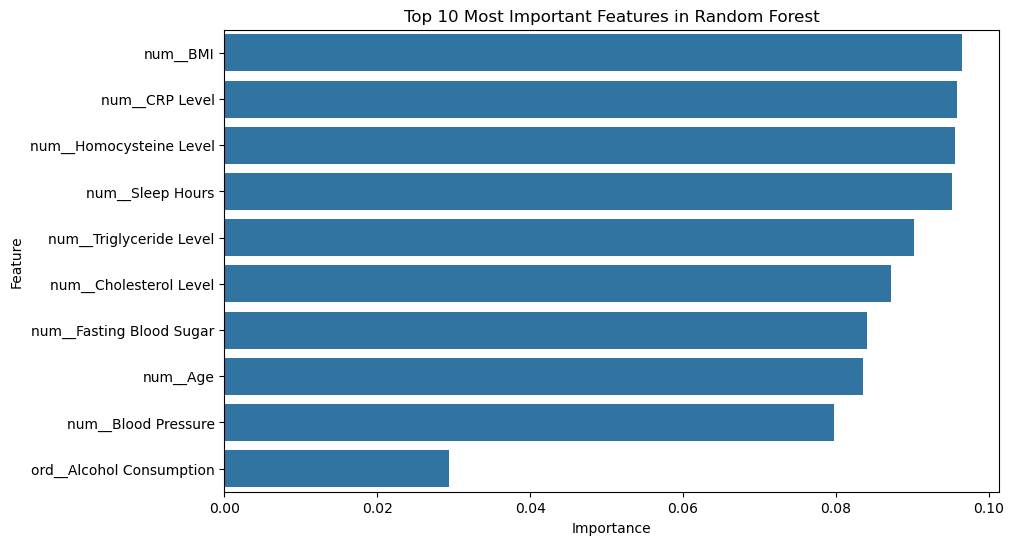

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature')
plt.title("Top 10 Most Important Features in Random Forest")
plt.show()

# Interpretation

Trees tend to favor continuous values and so to avoid overinterpreting the importance of each feature, logistic regression will be used to model the data as well.

Features will be pruned by comparing importance to the regression summaries and removing any features with high correlated features

In [ ]:
X_train_sm = X_train.copy()
X_test_sm = X_test.copy()

X_train_sm.columns = X_train_sm.columns.str.replace(' ', '_')
X_test_sm.columns  = X_test_sm.columns.str.replace(' ', '_')

# Combine X and y for statsmodels
df_sm = X_train_sm.copy()
df_sm['HeartDisease'] = y_train.values

# Create formula
formula = "HeartDisease ~ " + " + ".join(X_train_sm.columns)

# Fit logistic regression
logit_model = smf.glm(formula=formula,
                      data=df_sm,
                      family=sm.families.Binomial()).fit()

# View summary
print(logit_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:           HeartDisease   No. Observations:                 7625
Model:                            GLM   Df Residuals:                     7604
Model Family:                Binomial   Df Model:                           20
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3812.8
Date:                Sun, 07 Dec 2025   Deviance:                       7625.7
Time:                        16:09:48   Pearson chi2:                 7.62e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.002165
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

The regression summary tells us that almost all variables are individually statistically insignificant prior to pruning. It would be prudent to check correlations and residuals before moving forward.

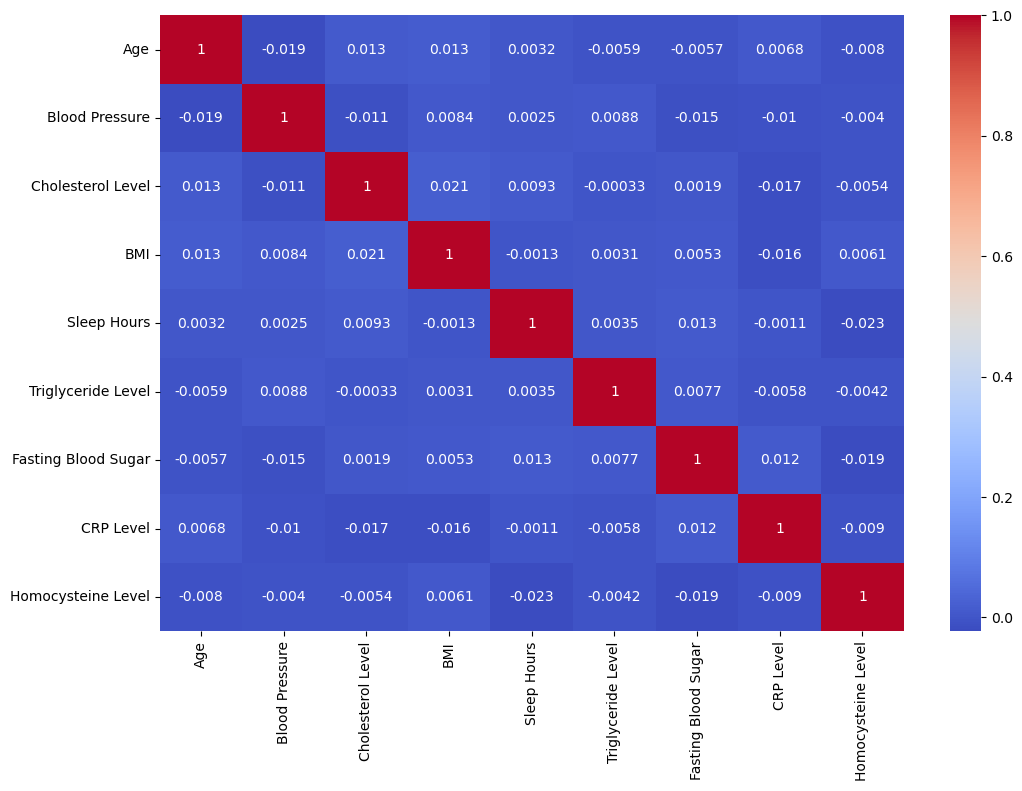

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize = (12, 8))
sns.heatmap(corr, annot = True, cmap='coolwarm')
plt.show()

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use your fully preprocessed training data
X_vif = X_train.copy()

# Add intercept
X_vif = sm.add_constant(X_vif)

# Compute VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

display(vif_data)

,feature,VIF
0,const,13.997759
1,num__Age,1.004507
2,num__Blood Pressure,1.002750
3,num__Cholesterol Level,1.002581
4,num__BMI,1.002031
5,num__Sleep Hours,1.001498
6,num__Triglyceride Level,1.001533
7,num__Fasting Blood Sugar,1.002496
8,num__CRP Level,1.002760
9,num__Homocysteine Level,1.002959


All columns have a vif of ~1 meaning none of the features can be used to explain the others and from the heatmap, the numerical columns also have low correlation.  The data  may very well be nonlinear since I would have expected some correlation with health diagnostics.

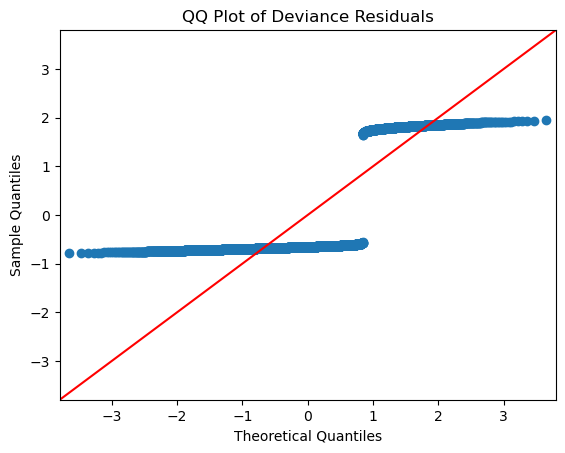

In [ ]:
residuals = logit_model.resid_deviance
fitted = logit_model.fittedvalues

sm.qqplot(residuals, line='45')
plt.title("QQ Plot of Deviance Residuals")
plt.show()

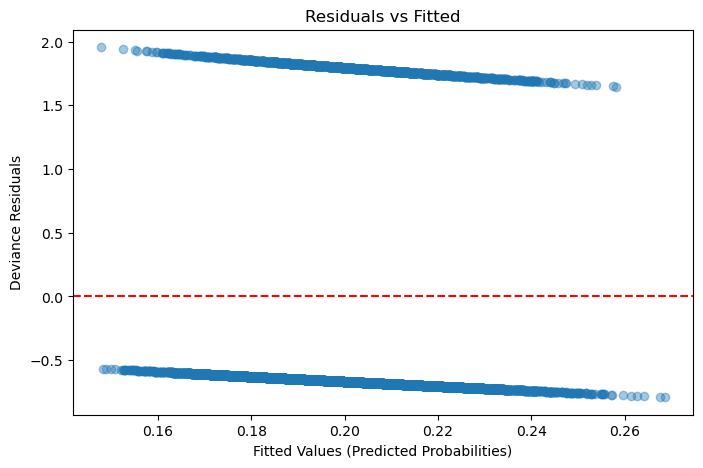

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(fitted, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values (Predicted Probabilities)")
plt.ylabel("Deviance Residuals")
plt.title("Residuals vs Fitted")
plt.show()

Both residual lines slope downward, but barely have any variability. This could mean many things, with weak predictors being among the explanations. Considering what the features are in relation to heart disease, these results do not make sense. To rule nonlinearity out, the random forest will be used to make evaluate the model.

In [ ]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1525
           1       0.00      0.00      0.00       382

    accuracy                           0.80      1907
   macro avg       0.40      0.50      0.44      1907
weighted avg       0.64      0.80      0.71      1907



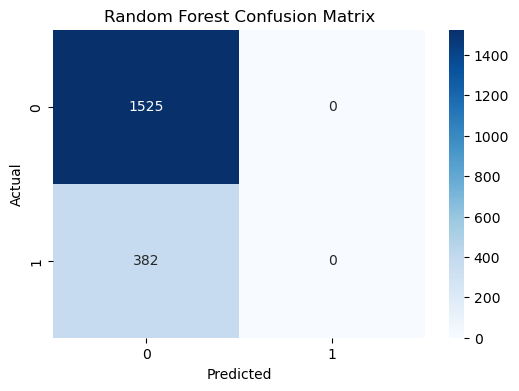

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Random Forest Confusion Matrix")
plt.show()


The confusion matrix revealed that the positive test cases are not being predicted. The class imbalance may have been too severe with this data. The analysis will be repeated using an equal distribution.

# Repeating workflow with new split

In [ ]:
# balances the data
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

df_all = X_train.copy()
df_all['target'] = y_train

df_pos = df_all[df_all['target'] == 1]
df_neg = df_all[df_all['target'] == 0].sample(len(df_pos), random_state=42)

df_balanced = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42)
X_train_bal = df_balanced.drop(columns=['target'])
y_train_bal = df_balanced['target']

# test train split on new balanced data
X_bal = df_balanced.drop(columns=['target'])
y_bal = df_balanced['target']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_bal, y_bal, test_size=0.10, random_state=42, shuffle=True
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight=None,
    max_depth=None,
    n_jobs=-1
)

rf.fit(X_train_new, y_train_new)


,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred_new = rf.predict(X_test_new)
print(classification_report(y_test_new, y_pred_new))

              precision    recall  f1-score   support

           0       0.49      0.54      0.51       147
           1       0.53      0.48      0.50       159

    accuracy                           0.51       306
   macro avg       0.51      0.51      0.51       306
weighted avg       0.51      0.51      0.51       306



With a baseline accuracy of about 50%, the model is no better than just randomly guessing. After testing for linear relationships and using random forest which doesn't require linearity within the data, among other reasons, the fault seems to lie within the data rather than the model. The predictive power within the features is not strong enough to return anything meaningful or the data was engineered rather than collected. It's common knowledge that the features used in the analysis share a connection with heart disease, and the model saying otherwise goes to show that something must be wrong with the data. This, as well as recent discussions from where the data was collected support this notion.